In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# Project paths
PROJECT_ROOT = Path("..")

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

CAUSAL_FILE = PROCESSED_DIR / "causal_panel.parquet"
CRIME_FILE = PROCESSED_DIR / "clean_crime.parquet"
OUTAGE_FILE = PROCESSED_DIR / "clean_streetlights.parquet"

COEFFICIENT_FILE = OUTPUT_DIR / "event_study_coefficients.csv"
PLOT_FILE = OUTPUT_DIR / "event_study_plot.png"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project paths initialized.")
print("Causal panel:", CAUSAL_FILE)
print("Crime data:", CRIME_FILE)
print("Outage data:", OUTAGE_FILE)

Project paths initialized.
Causal panel: ..\data\processed\causal_panel.parquet
Crime data: ..\data\processed\clean_crime.parquet
Outage data: ..\data\processed\clean_streetlights.parquet


In [2]:
# Load datasets

panel = pd.read_parquet(CAUSAL_FILE)
crime = gpd.read_parquet(CRIME_FILE)
outages = gpd.read_parquet(OUTAGE_FILE)

print("Causal panel shape:", panel.shape)
print("Crime data shape:", crime.shape)
print("Outage data shape:", outages.shape)

print("\nCausal panel columns:")
print(panel.columns.tolist())

print("\nCrime columns:")
print(crime.columns.tolist())

print("\nOutage columns:")
print(outages.columns.tolist())

Causal panel shape: (276744, 16)
Crime data shape: (63195, 38)
Outage data shape: (108030, 46)

Causal panel columns:
['pair_id', 'created_date', 'closed_date', 'location_key', 'period', 'period_order', 'treatment', 'post', 'treatment_x_post', 'crime_100m', 'crime_250m', 'baseline_crime_intensity', 'borough', 'outage_duration_hours', 'h3_res9', 'h3_res10']

Crime columns:
['cmplnt_num', 'cmplnt_fr_dt', 'cmplnt_fr_tm', 'cmplnt_to_dt', 'cmplnt_to_tm', 'addr_pct_cd', 'rpt_dt', 'ky_cd', 'ofns_desc', 'pd_cd', 'pd_desc', 'crm_atpt_cptd_cd', 'law_cat_cd', 'boro_nm', 'loc_of_occur_desc', 'prem_typ_desc', 'juris_desc', 'jurisdiction_code', 'parks_nm', 'hadevelopt', 'housing_psa', 'x_coord_cd', 'y_coord_cd', 'susp_age_group', 'susp_race', 'susp_sex', 'transit_district', 'latitude', 'longitude', 'lat_lon', 'patrol_boro', 'station_name', 'vic_age_group', 'vic_race', 'vic_sex', 'crime_datetime', 'is_nighttime', 'geometry']

Outage columns:
['unique_key', 'created_date', 'closed_date', 'agency', 'ag

In [3]:
# Inspect date ranges and timestamp types

for df_name, df, date_col in [
    ("Causal panel", panel, "created_date"),
    ("Crime", crime, "crime_datetime"),
    ("Outages", outages, "created_date"),
]:
    print(f"\n{df_name}")
    print("-" * len(df_name))
    print(f"{date_col} dtype:", df[date_col].dtype)
    print(f"Minimum: {df[date_col].min()}")
    print(f"Maximum: {df[date_col].max()}")
    print(f"Missing: {df[date_col].isna().sum()}")

print("\nCausal panel periods:")
print(panel["period"].value_counts().sort_index())

print("\nTreatment/control counts:")
print(panel["treatment"].value_counts().sort_index())

print("\nUnique treatment events:")
print(panel.loc[panel["treatment"] == 1, "pair_id"].nunique())

print("\nUnique control-pair observations:")
print(panel.loc[panel["treatment"] == 0, "pair_id"].nunique())


Causal panel
------------
created_date dtype: datetime64[us]
Minimum: 2020-01-01 06:55:00
Maximum: 2026-09-15 15:54:00
Missing: 0

Crime
-----
crime_datetime dtype: datetime64[us]
Minimum: 1975-05-24 23:00:00
Maximum: 2025-12-31 22:50:00
Missing: 0

Outages
-------
created_date dtype: datetime64[us]
Minimum: 2020-01-01 00:45:00
Maximum: 2026-09-16 21:39:00
Missing: 0

Causal panel periods:
period
during    92248
post      92248
pre       92248
Name: count, dtype: int64

Treatment/control counts:
treatment
0    138372
1    138372
Name: count, dtype: int64

Unique treatment events:
46124

Unique control-pair observations:
46124


In [4]:
# Check event-study time coverage relative to outage start dates

treatment_events = (
    panel.loc[panel["treatment"] == 1,
              ["pair_id", "created_date"]]
    .drop_duplicates()
    .copy()
)

crime_max = crime["crime_datetime"].max()
crime_min = crime["crime_datetime"].min()

treatment_events["latest_required_date"] = (
    treatment_events["created_date"] + pd.Timedelta(days=35)
)

treatment_events["earliest_required_date"] = (
    treatment_events["created_date"] - pd.Timedelta(days=28)
)

treatment_events["has_full_pre_window"] = (
    treatment_events["earliest_required_date"] >= crime_min
)

treatment_events["has_full_post_window"] = (
    treatment_events["latest_required_date"] <= crime_max
)

print("Crime data coverage:")
print(f"  Start: {crime_min}")
print(f"  End:   {crime_max}")

print("\nTreatment events:")
print(f"  Total events: {len(treatment_events):,}")
print(
    f"  Full -4 to -1 week coverage: "
    f"{treatment_events['has_full_pre_window'].sum():,}"
)
print(
    f"  Full 0 to +4 week coverage: "
    f"{treatment_events['has_full_post_window'].sum():,}"
)

print("\nEvents without complete +4-week coverage:")
print(
    treatment_events.loc[
        ~treatment_events["has_full_post_window"],
        "created_date"
    ].agg(["min", "max"])
)

print("\nNumber of treatment events by creation year:")
print(
    treatment_events["created_date"]
    .dt.year
    .value_counts()
    .sort_index()
)

Crime data coverage:
  Start: 1975-05-24 23:00:00
  End:   2025-12-31 22:50:00

Treatment events:
  Total events: 46,124
  Full -4 to -1 week coverage: 46,124
  Full 0 to +4 week coverage: 39,148

Events without complete +4-week coverage:
min   2025-11-26 23:00:00
max   2026-09-15 15:54:00
Name: created_date, dtype: datetime64[us]

Number of treatment events by creation year:
created_date
2020    5663
2021    5575
2022    6295
2023    5635
2024    7533
2025    9312
2026    6111
Name: count, dtype: int64


In [5]:
# Build one row per treatment event with its event date and location

treatment_events = (
    panel.loc[
        panel["treatment"] == 1,
        [
            "pair_id",
            "location_key",
            "created_date",
            "closed_date",
            "borough",
            "h3_res9",
            "h3_res10",
        ],
    ]
    .drop_duplicates(subset=["pair_id"])
    .copy()
)

# Make sure timestamps are datetime
treatment_events["created_date"] = pd.to_datetime(
    treatment_events["created_date"]
)
treatment_events["closed_date"] = pd.to_datetime(
    treatment_events["closed_date"]
)

print("Treatment-event table shape:", treatment_events.shape)
print("\nColumns:")
print(treatment_events.columns.tolist())

print("\nDuplicate pair IDs:")
print(treatment_events["pair_id"].duplicated().sum())

print("\nDuplicate location keys:")
print(treatment_events["location_key"].duplicated().sum())

print("\nFirst 5 treatment events:")
display(treatment_events.head())

Treatment-event table shape: (46124, 7)

Columns:
['pair_id', 'location_key', 'created_date', 'closed_date', 'borough', 'h3_res9', 'h3_res10']

Duplicate pair IDs:
0

Duplicate location keys:
0

First 5 treatment events:


,pair_id,location_key,created_date,closed_date,borough,h3_res9,h3_res10
0,45284934_48296388,45284934,2020-01-01 11:04:00,2020-01-04 00:05:00,MANHATTAN,892a1072dcfffff,8a2a1072dce7fff
6,45284935_64135128,45284935,2020-01-01 06:55:00,2020-01-03 10:54:00,MANHATTAN,892a1072137ffff,8a2a1072134ffff
12,45285212_64845276,45285212,2020-01-01 18:19:00,2020-01-06 09:16:00,STATEN ISLAND,892a10625cfffff,8a2a10625ccffff
18,45285700_48430637,45285700,2020-01-01 20:11:00,2020-01-06 09:27:00,STATEN ISLAND,892a107560fffff,8a2a107560f7fff
24,45286571_53726952,45286571,2020-01-01 15:26:00,2020-01-03 12:15:00,BROOKLYN,892a1072d2bffff,8a2a1072d28ffff


In [6]:
# Prepare crime events for spatial event-time analysis

crime_es = crime[
    [
        "crime_datetime",
        "geometry",
    ]
].copy()

crime_es["crime_datetime"] = pd.to_datetime(
    crime_es["crime_datetime"],
    errors="coerce"
)

crime_es = crime_es.dropna(
    subset=["crime_datetime", "geometry"]
).copy()

# Use the same projected CRS used in Stages 6–9.
crime_es = crime_es.to_crs(epsg=2263)

# Keep a unique identifier for each crime event.
crime_es["crime_id"] = np.arange(len(crime_es))

print("Crime events available for event study:", len(crime_es))
print("Crime CRS:", crime_es.crs)
print("Crime date range:")
print("  Start:", crime_es["crime_datetime"].min())
print("  End:  ", crime_es["crime_datetime"].max())

Crime events available for event study: 63195
Crime CRS: EPSG:2263
Crime date range:
  Start: 1975-05-24 23:00:00
  End:   2025-12-31 22:50:00


In [7]:
# Build treatment and control event-study units
# Controls use the treatment outage's created_date as their event date.

event_units = panel[
    [
        "pair_id",
        "location_key",
        "created_date",
        "closed_date",
        "treatment",
        "borough",
        "h3_res9",
        "h3_res10",
    ]
].drop_duplicates().copy()

# Each pair should have exactly one treatment and one control location.
event_units["created_date"] = pd.to_datetime(
    event_units["created_date"]
)
event_units["closed_date"] = pd.to_datetime(
    event_units["closed_date"]
)

print("Event-study units:", len(event_units))
print("Unique pairs:", event_units["pair_id"].nunique())
print("\nTreatment/control units:")
print(event_units["treatment"].value_counts().sort_index())

print("\nUnique locations:")
print(event_units["location_key"].nunique())

# Prepare a lookup of actual outage geometries.
outage_geometry = outages[
    ["unique_key", "geometry"]
].copy()

outage_geometry["unique_key"] = pd.to_numeric(
    outage_geometry["unique_key"],
    errors="coerce"
)

outage_geometry = outage_geometry.dropna(
    subset=["unique_key", "geometry"]
).copy()

outage_geometry["unique_key"] = (
    outage_geometry["unique_key"].astype(int)
)

# Keep one geometry per outage key.
outage_geometry = outage_geometry.drop_duplicates(
    subset=["unique_key"]
)

# Attach geometry to each event-study unit.
event_units = event_units.merge(
    outage_geometry.rename(
        columns={
            "unique_key": "location_key",
            "geometry": "location_geometry",
        }
    ),
    on="location_key",
    how="left",
)

print("\nMissing event-unit geometries:")
print(event_units["location_geometry"].isna().sum())

print("\nEvent-unit CRS source:", outages.crs)

Event-study units: 92248
Unique pairs: 46124

Treatment/control units:
treatment
0    46124
1    46124
Name: count, dtype: int64

Unique locations:
46124

Missing event-unit geometries:
0

Event-unit CRS source: {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "GeographicCRS", "name": "WGS 84", "datum_ensemble": {"name": "World Geodetic System 1984 ensemble", "members": [{"name": "World Geodetic System 1984 (Transit)"}, {"name": "World Geodetic System 1984 (G730)"}, {"name": "World Geodetic System 1984 (G873)"}, {"name": "World Geodetic System 1984 (G1150)"}, {"name": "World Geodetic System 1984 (G1674)"}, {"name": "World Geodetic System 1984 (G1762)"}, {"name": "World Geodetic System 1984 (G2139)"}, {"name": "World Geodetic System 1984 (G2296)"}], "ellipsoid": {"name": "WGS 84", "semi_major_axis": 6378137, "inverse_flattening": 298.257223563}, "accuracy": "2.0", "id": {"authority": "EPSG", "code": 6326}}, "coordinate_system": {"subtype": "ellipsoidal", "axis":

In [8]:
from scipy.spatial import cKDTree

# Convert event-unit geometries to the projected NYC CRS.
event_units_gdf = gpd.GeoDataFrame(
    event_units,
    geometry="location_geometry",
    crs=outages.crs,
)

event_units_gdf = event_units_gdf.to_crs(epsg=2263)

# Extract point coordinates for efficient spatial lookup.
event_coords = np.column_stack(
    [
        event_units_gdf.geometry.x.to_numpy(),
        event_units_gdf.geometry.y.to_numpy(),
    ]
)

crime_coords = np.column_stack(
    [
        crime_es.geometry.x.to_numpy(),
        crime_es.geometry.y.to_numpy(),
    ]
)

# Build a KD-tree for crime locations.
crime_tree = cKDTree(crime_coords)

print("Event units CRS:", event_units_gdf.crs)
print("Event-unit coordinates:", event_coords.shape)
print("Crime coordinates:", crime_coords.shape)

print("\nSpatial radius:")
print("Direct treatment radius: 100 meters")

# Quick sanity check: find crimes within 100 m of the first event unit.
first_neighbors = crime_tree.query_ball_point(
    event_coords[0],
    r=100,
)

print(
    "\nCrimes within 100 m of first event-study location:",
    len(first_neighbors),
)

Event units CRS: EPSG:2263
Event-unit coordinates: (92248, 2)
Crime coordinates: (63195, 2)

Spatial radius:
Direct treatment radius: 100 meters

Crimes within 100 m of first event-study location: 0


In [9]:
# Keep only treatment events with complete -4 to +4 week coverage.
# Controls inherit the same event date as their matched treatment.

crime_min = crime_es["crime_datetime"].min()
crime_max = crime_es["crime_datetime"].max()

event_units_gdf["earliest_required"] = (
    event_units_gdf["created_date"] - pd.Timedelta(days=35)
)

event_units_gdf["latest_required"] = (
    event_units_gdf["created_date"] + pd.Timedelta(days=35)
)

event_units_gdf["complete_event_window"] = (
    (event_units_gdf["earliest_required"] >= crime_min)
    & (event_units_gdf["latest_required"] <= crime_max)
)

# Keep complete treatment-control pairs.
complete_pairs = (
    event_units_gdf
    .groupby("pair_id")["complete_event_window"]
    .all()
)

complete_pair_ids = complete_pairs[
    complete_pairs
].index

event_units_complete = event_units_gdf[
    event_units_gdf["pair_id"].isin(complete_pair_ids)
].copy()

print("Complete treatment-control pairs:", len(complete_pair_ids))
print("Event-study units retained:", len(event_units_complete))

print("\nTreatment/control counts:")
print(
    event_units_complete["treatment"]
    .value_counts()
    .sort_index()
)

print("\nDropped pairs:", len(complete_pairs) - len(complete_pair_ids))

Complete treatment-control pairs: 39148
Event-study units retained: 78296

Treatment/control counts:
treatment
0    39148
1    39148
Name: count, dtype: int64

Dropped pairs: 6976


In [14]:
# Calculate 0–100 m crime counts for relative weeks -4 through +4.

RELATIVE_WEEKS = [-4, -3, -2, -1, 0, 1, 2, 3, 4]

# Each interval is [start_day, end_day).
WEEK_WINDOWS = {
    -4: (-35, -28),
    -3: (-28, -21),
    -2: (-21, -14),
    -1: (-14, -7),
     0: (0, 7),
     1: (7, 14),
     2: (14, 21),
     3: (21, 28),
     4: (28, 35),
}

crime_times = crime_es["crime_datetime"].to_numpy()

event_rows = []

for _, row in event_units_complete.iterrows():

    # Find cleaned crime events within 100 m.
    point_geometry = row["location_geometry"]

    if point_geometry is None or point_geometry.is_empty:
        continue

    point = [point_geometry.x, point_geometry.y]

    neighbor_idx = crime_tree.query_ball_point(
        point,
        r=100,
    )

    if not neighbor_idx:
        # Create all nine event-time observations with zero crimes.
        for rel_week in RELATIVE_WEEKS:
            event_rows.append(
                {
                    "pair_id": row["pair_id"],
                    "location_key": row["location_key"],
                    "treatment": row["treatment"],
                    "created_date": row["created_date"],
                    "rel_week": rel_week,
                    "crime_count": 0,
                    "borough": row["borough"],
                    "h3_res9": row["h3_res9"],
                    "h3_res10": row["h3_res10"],
                }
            )
        continue

    # Crime timestamps for nearby crimes.
    nearby_times = crime_times[neighbor_idx]

    # Elapsed days relative to outage start.
    elapsed_days = (
        nearby_times - np.datetime64(row["created_date"])
    ) / np.timedelta64(1, "D")

    for rel_week, (start_day, end_day) in WEEK_WINDOWS.items():

        count = int(
            np.sum(
                (elapsed_days >= start_day)
                & (elapsed_days < end_day)
            )
        )

        event_rows.append(
            {
                "pair_id": row["pair_id"],
                "location_key": row["location_key"],
                "treatment": row["treatment"],
                "created_date": row["created_date"],
                "rel_week": rel_week,
                "crime_count": count,
                "borough": row["borough"],
                "h3_res9": row["h3_res9"],
                "h3_res10": row["h3_res10"],
            }
        )

event_study = pd.DataFrame(event_rows)

print("Event-study dataset shape:", event_study.shape)
print("Expected rows:", len(complete_pair_ids) * 2 * 9)

print("\nRelative-week counts:")
print(
    event_study["rel_week"]
    .value_counts()
    .sort_index()
)

print("\nTreatment/control rows:")
print(
    event_study["treatment"]
    .value_counts()
    .sort_index()
)

print("\nCrime count summary:")
print(event_study["crime_count"].describe())

print("\nNon-zero crime observations:")
print(
    (event_study["crime_count"] > 0).sum()
)

Event-study dataset shape: (704664, 9)
Expected rows: 704664

Relative-week counts:
rel_week
-4    78296
-3    78296
-2    78296
-1    78296
 0    78296
 1    78296
 2    78296
 3    78296
 4    78296
Name: count, dtype: int64

Treatment/control rows:
treatment
0    352332
1    352332
Name: count, dtype: int64

Crime count summary:
count    704664.000000
mean          0.002837
std           0.064695
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          10.000000
Name: crime_count, dtype: float64

Non-zero crime observations:
1720


In [15]:
# Validate the event-study dataset

print("=== Event Study Validation ===")

# Expected unique unit-week combinations
unique_combinations = event_study[
    ["pair_id", "location_key", "rel_week"]
].drop_duplicates()

print("\nUnique pair-location-week combinations:")
print(len(unique_combinations))

print("Expected:")
print(len(complete_pair_ids) * 2 * 9)

# Check duplicates
duplicates = event_study.duplicated(
    subset=["pair_id", "location_key", "rel_week"]
).sum()

print("\nDuplicate unit-week observations:", duplicates)

# Missing values
print("\nMissing values:")
print(
    event_study[
        [
            "pair_id",
            "location_key",
            "created_date",
            "rel_week",
            "treatment",
            "crime_count",
        ]
    ].isna().sum()
)

# Check treatment is constant within each pair/location
treatment_variation = (
    event_study
    .groupby(["pair_id", "location_key"])["treatment"]
    .nunique()
)

print(
    "\nUnits with changing treatment status:",
    (treatment_variation > 1).sum()
)

# Check that each unit has all 9 event weeks
weeks_per_unit = (
    event_study
    .groupby(["pair_id", "location_key"])["rel_week"]
    .nunique()
)

print(
    "Units missing one or more event weeks:",
    (weeks_per_unit != 9).sum()
)

# Show event-study count means by treatment and relative week
event_means = (
    event_study
    .groupby(["rel_week", "treatment"])["crime_count"]
    .mean()
    .unstack()
    .rename(columns={
        0: "control_mean",
        1: "treatment_mean"
    })
)

print("\nMean 0–100 m crime count by event week:")
display(event_means)

=== Event Study Validation ===

Unique pair-location-week combinations:
704664
Expected:
704664

Duplicate unit-week observations: 0

Missing values:
pair_id         0
location_key    0
created_date    0
rel_week        0
treatment       0
crime_count     0
dtype: int64

Units with changing treatment status: 0
Units missing one or more event weeks: 0

Mean 0–100 m crime count by event week:


treatment,control_mean,treatment_mean
rel_week,,
-4,0.002682,0.002810
-3,0.003193,0.002299
-2,0.002733,0.002631
-1,0.003091,0.002376
0,0.003193,0.002248
1,0.003244,0.002631
2,0.002759,0.003934
3,0.002938,0.003142
4,0.002835,0.002325


In [16]:
# Create event-time dummy variables.
# Week -1 is deliberately omitted as the reference period.

EVENT_WEEKS = [-4, -3, -2, 0, 1, 2, 3, 4]

for week in EVENT_WEEKS:
    event_study[f"event_{week}"] = (
        event_study["rel_week"] == week
    ).astype(int)

# Treatment × event-time interactions.
for week in EVENT_WEEKS:
    event_study[f"treat_event_{week}"] = (
        event_study["treatment"]
        * event_study[f"event_{week}"]
    )

print("Event-study variables created.")

print("\nRegression event weeks:")
print(EVENT_WEEKS)

print("\nNew columns:")
print([
    col
    for col in event_study.columns
    if col.startswith("event_")
    or col.startswith("treat_event_")
])

print("\nBaseline week -1 present:")
print((event_study["rel_week"] == -1).sum())

print("Baseline dummy created:")
print("No — week -1 is the omitted reference category.")

Event-study variables created.

Regression event weeks:
[-4, -3, -2, 0, 1, 2, 3, 4]

New columns:
['event_-4', 'event_-3', 'event_-2', 'event_0', 'event_1', 'event_2', 'event_3', 'event_4', 'treat_event_-4', 'treat_event_-3', 'treat_event_-2', 'treat_event_0', 'treat_event_1', 'treat_event_2', 'treat_event_3', 'treat_event_4']

Baseline week -1 present:
78296
Baseline dummy created:
No — week -1 is the omitted reference category.


In [17]:
# Create event-time dummy variables.
# Week -1 is deliberately omitted as the reference period.

EVENT_WEEKS = [-4, -3, -2, 0, 1, 2, 3, 4]

for week in EVENT_WEEKS:
    event_study[f"event_{week}"] = (
        event_study["rel_week"] == week
    ).astype(int)

# Treatment × event-time interactions.
for week in EVENT_WEEKS:
    event_study[f"treat_event_{week}"] = (
        event_study["treatment"]
        * event_study[f"event_{week}"]
    )

print("Event-study variables created.")

print("\nRegression event weeks:")
print(EVENT_WEEKS)

print("\nNew columns:")
print([
    col
    for col in event_study.columns
    if col.startswith("event_")
    or col.startswith("treat_event_")
])

print("\nBaseline week -1 present:")
print((event_study["rel_week"] == -1).sum())

print("Baseline dummy created:")
print("No — week -1 is the omitted reference category.")

Event-study variables created.

Regression event weeks:
[-4, -3, -2, 0, 1, 2, 3, 4]

New columns:
['event_-4', 'event_-3', 'event_-2', 'event_0', 'event_1', 'event_2', 'event_3', 'event_4', 'treat_event_-4', 'treat_event_-3', 'treat_event_-2', 'treat_event_0', 'treat_event_1', 'treat_event_2', 'treat_event_3', 'treat_event_4']

Baseline week -1 present:
78296
Baseline dummy created:
No — week -1 is the omitted reference category.


In [23]:
# Efficient event-study estimation with location and time fixed effects
# This avoids creating 42,000+ dummy-variable columns.

import statsmodels.api as sm

SAFE_EVENT_NAMES = {
    -4: "treat_event_m4",
    -3: "treat_event_m3",
    -2: "treat_event_m2",
     0: "treat_event_0",
     1: "treat_event_p1",
     2: "treat_event_p2",
     3: "treat_event_p3",
     4: "treat_event_p4",
}

interaction_terms = list(SAFE_EVENT_NAMES.values())

# Variables needed for the fixed-effects transformation
model_data = event_study[
    ["crime_count", "location_key", "rel_week"] + interaction_terms
].copy()

print("Original observations:", len(model_data))
print("Unique locations:", model_data["location_key"].nunique())
print("Event weeks:", sorted(model_data["rel_week"].unique()))

# ---------------------------------------------------------
# Two-way within transformation
# Removes:
#   1. location fixed effects
#   2. relative-week fixed effects
#
# For each variable:
# X_it* = X_it - X_i. - X_.t + X_..
# ---------------------------------------------------------

variables = ["crime_count"] + interaction_terms

grand_means = model_data[variables].mean()

location_means = (
    model_data
    .groupby("location_key")[variables]
    .transform("mean")
)

week_means = (
    model_data
    .groupby("rel_week")[variables]
    .transform("mean")
)

demeaned = (
    model_data[variables]
    - location_means
    - week_means
    + grand_means
)

y = demeaned["crime_count"]
X = demeaned[interaction_terms]

# Add no constant:
# location and time fixed effects have already been removed.
efficient_model = sm.OLS(y, X).fit(
    cov_type="cluster",
    cov_kwds={"groups": model_data["location_key"]}
)

print("\nEvent-study regression completed successfully.")

print("Number of observations:", int(efficient_model.nobs))
print("Number of location clusters:", model_data["location_key"].nunique())

print("\nEvent-study interaction coefficients:")
print(efficient_model.params)

print("\nStandard errors:")
print(efficient_model.bse)

print("\n95% confidence intervals:")
print(efficient_model.conf_int())

print("\nP-values:")
print(efficient_model.pvalues)

Original observations: 704664
Unique locations: 42247
Event weeks: [np.int64(-4), np.int64(-3), np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Event-study regression completed successfully.
Number of observations: 704664
Number of location clusters: 42247

Event-study interaction coefficients:
treat_event_m4    0.000309
treat_event_m3   -0.000713
treat_event_m2    0.000079
treat_event_0    -0.000764
treat_event_p1   -0.000432
treat_event_p2    0.001356
treat_event_p3    0.000386
treat_event_p4   -0.000330
dtype: float64

Standard errors:
treat_event_m4    0.000544
treat_event_m3    0.000502
treat_event_m2    0.000476
treat_event_0     0.000492
treat_event_p1    0.000470
treat_event_p2    0.000591
treat_event_p3    0.000565
treat_event_p4    0.000466
dtype: float64

95% confidence intervals:
                       0         1
treat_event_m4 -0.000757  0.001375
treat_event_m3 -0.001697  0.000271
treat_event_m2 -0.000853  0.001011
treat_event

In [24]:
# Extract event-study coefficients into a clean results table

results_rows = []

for week, safe_name in SAFE_EVENT_NAMES.items():
    coef = efficient_model.params[safe_name]
    se = efficient_model.bse[safe_name]
    ci_low, ci_high = efficient_model.conf_int().loc[safe_name]
    p_value = efficient_model.pvalues[safe_name]

    results_rows.append({
        "rel_week": week,
        "coefficient": coef,
        "std_error": se,
        "ci_lower": ci_low,
        "ci_upper": ci_high,
        "p_value": p_value,
    })

event_study_results = pd.DataFrame(results_rows).sort_values("rel_week")

print("Event-study results:")
display(event_study_results)

print("\nPre-treatment coefficients:")
display(
    event_study_results[
        event_study_results["rel_week"] < -1
    ]
)

print("\nPost-treatment coefficients:")
display(
    event_study_results[
        event_study_results["rel_week"] >= 0
    ]
)

Event-study results:


,rel_week,coefficient,std_error,ci_lower,ci_upper,p_value
0,-4,0.000309,0.000544,-0.000757,0.001375,0.570024
1,-3,-0.000713,0.000502,-0.001697,0.000271,0.155620
2,-2,0.000079,0.000476,-0.000853,0.001011,0.868115
3,0,-0.000764,0.000492,-0.001729,0.000201,0.120565
4,1,-0.000432,0.000470,-0.001353,0.000490,0.358272
5,2,0.001356,0.000591,0.000197,0.002515,0.021817
6,3,0.000386,0.000565,-0.000721,0.001492,0.494819
7,4,-0.000330,0.000466,-0.001243,0.000584,0.479239



Pre-treatment coefficients:


,rel_week,coefficient,std_error,ci_lower,ci_upper,p_value
0,-4,0.000309,0.000544,-0.000757,0.001375,0.570024
1,-3,-0.000713,0.000502,-0.001697,0.000271,0.155620
2,-2,0.000079,0.000476,-0.000853,0.001011,0.868115



Post-treatment coefficients:


,rel_week,coefficient,std_error,ci_lower,ci_upper,p_value
3,0,-0.000764,0.000492,-0.001729,0.000201,0.120565
4,1,-0.000432,0.000470,-0.001353,0.000490,0.358272
5,2,0.001356,0.000591,0.000197,0.002515,0.021817
6,3,0.000386,0.000565,-0.000721,0.001492,0.494819
7,4,-0.000330,0.000466,-0.001243,0.000584,0.479239


In [26]:
# Formal joint test of the pre-treatment coefficients
# H0: coefficients at -4, -3, and -2 are jointly equal to zero.

pretrend_test = efficient_model.wald_test(
    "treat_event_m4 = 0, "
    "treat_event_m3 = 0, "
    "treat_event_m2 = 0"
)

print("Joint parallel-trends test")
print("--------------------------------")
print("F-statistic:", float(pretrend_test.statistic))
print("p-value:", float(pretrend_test.pvalue))

if float(pretrend_test.pvalue) >= 0.05:
    print("\nPre-treatment coefficients are jointly not statistically different from zero.")
else:
    print("\nPre-treatment coefficients are jointly statistically different from zero.")

Joint parallel-trends test
--------------------------------
F-statistic: 3.5467415451576847
p-value: 0.314750306749955

Pre-treatment coefficients are jointly not statistically different from zero.


In [27]:
# Add the omitted -1 baseline to the event-study results

baseline_row = pd.DataFrame([{
    "rel_week": -1,
    "coefficient": 0.0,
    "std_error": np.nan,
    "ci_lower": np.nan,
    "ci_upper": np.nan,
    "p_value": np.nan,
}])

event_study_results_final = (
    pd.concat([event_study_results, baseline_row], ignore_index=True)
    .sort_values("rel_week")
    .reset_index(drop=True)
)

print("Final event-study coefficient table:")
display(event_study_results_final)

Final event-study coefficient table:


,rel_week,coefficient,std_error,ci_lower,ci_upper,p_value
0,-4,0.000309,0.000544,-0.000757,0.001375,0.570024
1,-3,-0.000713,0.000502,-0.001697,0.000271,0.155620
2,-2,0.000079,0.000476,-0.000853,0.001011,0.868115
3,-1,0.000000,NaN,NaN,NaN,NaN
4,0,-0.000764,0.000492,-0.001729,0.000201,0.120565
5,1,-0.000432,0.000470,-0.001353,0.000490,0.358272
6,2,0.001356,0.000591,0.000197,0.002515,0.021817
7,3,0.000386,0.000565,-0.000721,0.001492,0.494819
8,4,-0.000330,0.000466,-0.001243,0.000584,0.479239


In [28]:
# Save event-study coefficients

event_study_results_final.to_csv(
    COEFFICIENT_FILE,
    index=False
)

print("Event-study coefficients saved successfully.")
print("File:", COEFFICIENT_FILE)
print("Rows:", len(event_study_results_final))

print("\nSaved results:")
display(event_study_results_final)

Event-study coefficients saved successfully.
File: ..\outputs\event_study_coefficients.csv
Rows: 9

Saved results:


,rel_week,coefficient,std_error,ci_lower,ci_upper,p_value
0,-4,0.000309,0.000544,-0.000757,0.001375,0.570024
1,-3,-0.000713,0.000502,-0.001697,0.000271,0.155620
2,-2,0.000079,0.000476,-0.000853,0.001011,0.868115
3,-1,0.000000,NaN,NaN,NaN,NaN
4,0,-0.000764,0.000492,-0.001729,0.000201,0.120565
5,1,-0.000432,0.000470,-0.001353,0.000490,0.358272
6,2,0.001356,0.000591,0.000197,0.002515,0.021817
7,3,0.000386,0.000565,-0.000721,0.001492,0.494819
8,4,-0.000330,0.000466,-0.001243,0.000584,0.479239


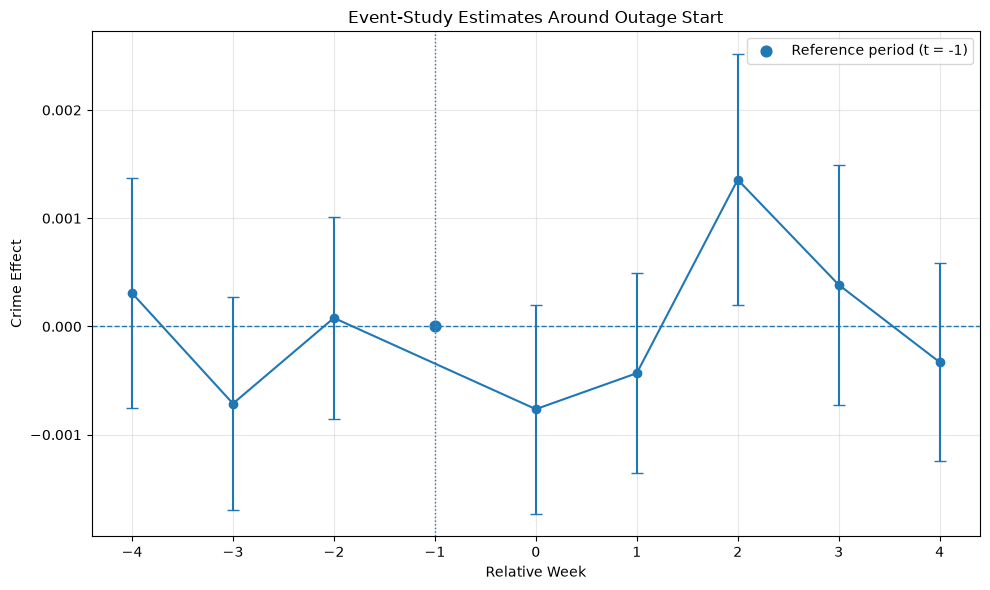

Event-study plot saved successfully.
File: ..\outputs\event_study_plot.png


In [29]:
# Create and save the event-study plot

plot_data = event_study_results_final.copy()

fig, ax = plt.subplots(figsize=(10, 6))

# Plot point estimates with 95% confidence intervals
non_baseline = plot_data["rel_week"] != -1

ax.errorbar(
    plot_data.loc[non_baseline, "rel_week"],
    plot_data.loc[non_baseline, "coefficient"],
    yerr=[
        plot_data.loc[non_baseline, "coefficient"]
        - plot_data.loc[non_baseline, "ci_lower"],
        plot_data.loc[non_baseline, "ci_upper"]
        - plot_data.loc[non_baseline, "coefficient"],
    ],
    fmt="o-",
    capsize=4,
    linewidth=1.5,
)

# Show the omitted -1 baseline
ax.scatter(
    -1,
    0,
    marker="o",
    s=60,
    label="Reference period (t = -1)",
)

# Reference lines
ax.axhline(0, linestyle="--", linewidth=1)
ax.axvline(-1, linestyle=":", linewidth=1)

ax.set_xlabel("Relative Week")
ax.set_ylabel("Crime Effect")
ax.set_title("Event-Study Estimates Around Outage Start")

ax.set_xticks([-4, -3, -2, -1, 0, 1, 2, 3, 4])

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()

fig.savefig(
    PLOT_FILE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Event-study plot saved successfully.")
print("File:", PLOT_FILE)